In [3]:
#import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
df=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Machine Learning/cardata.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


In [7]:
df.shape

(301, 9)

In [8]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [10]:
df['Fuel_Type'].value_counts()

,count
Fuel_Type,
Petrol,239
Diesel,60
CNG,2


In [11]:
df['Seller_Type'].value_counts()

,count
Seller_Type,
Dealer,195
Individual,106


In [12]:
df['Transmission'].value_counts()

,count
Transmission,
Manual,261
Automatic,40


In [13]:
df=pd.get_dummies(df,columns=['Fuel_Type','Seller_Type','Transmission'])

In [14]:
df

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,False,False,True,True,False,False,True
1,sx4,2013,4.75,9.54,43000,0,False,True,False,True,False,False,True
2,ciaz,2017,7.25,9.85,6900,0,False,False,True,True,False,False,True
3,wagon r,2011,2.85,4.15,5200,0,False,False,True,True,False,False,True
4,swift,2014,4.60,6.87,42450,0,False,True,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,0,False,True,False,True,False,False,True
297,brio,2015,4.00,5.90,60000,0,False,False,True,True,False,False,True
298,city,2009,3.35,11.00,87934,0,False,False,True,True,False,False,True
299,city,2017,11.50,12.50,9000,0,False,True,False,True,False,False,True


In [15]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Owner', 'Fuel_Type_CNG', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol',
       'Seller_Type_Dealer', 'Seller_Type_Individual',
       'Transmission_Automatic', 'Transmission_Manual'],
      dtype='object')

In [16]:
#create feature matrix x by dropping car_name and selling_price columns
x=df.drop(['Car_Name','Selling_Price'],axis=1)
print("Feature matrix X created  by dropping 'car_name' and 'selling_price' columns")

Feature matrix X created  by dropping 'car_name' and 'selling_price' columns


In [17]:
#create target variable y by selecting selling_price column
y=df['Selling_Price']
print("Target vector y created by selecting 'selling_price' column")

Target vector y created by selecting 'selling_price' column


In [18]:
y.head()

,Selling_Price
0,3.35
1,4.75
2,7.25
3,2.85
4,4.60


In [19]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Dataset split into training and testing sets")

Dataset split into training and testing sets


In [20]:
model=LinearRegression()
print("Linear regression model created")

Linear regression model created


In [24]:
y_train_pred=model.predict(x_train)
y_test_pred=model.predict(x_test)
print("Predictions generated for training and testing data")

Predictions generated for training and testing data


In [25]:
model.fit(x_train,y_train)
print("Model trained on training data")

Model trained on training data


In [26]:
mae = mean_absolute_error(y_train, y_train_pred)
mse = mean_squared_error(y_train, y_train_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_train_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 1.1675804448342353
Mean Squared Error (MSE): 2.9437205399630173
Root MSE (RMSE): 1.7157274084081706
R2 Score: 0.8886517300804558


In [27]:
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 1.216225682130144
Mean Squared Error (MSE): 3.4788039706448317
Root MSE (RMSE): 1.8651552135532399
R2 Score: 0.8489813024896058


In [ ]:
model.coef_

array([ 3.53801365e-01,  4.29152503e-01, -6.15725866e-06, -9.03759824e-01,
       -1.09057894e+00,  1.44269365e+00, -3.52114710e-01,  5.95296453e-01,
       -5.95296453e-01,  8.19510777e-01, -8.19510777e-01])

In [ ]:
model.intercept_

np.float64(-710.2771513359723)

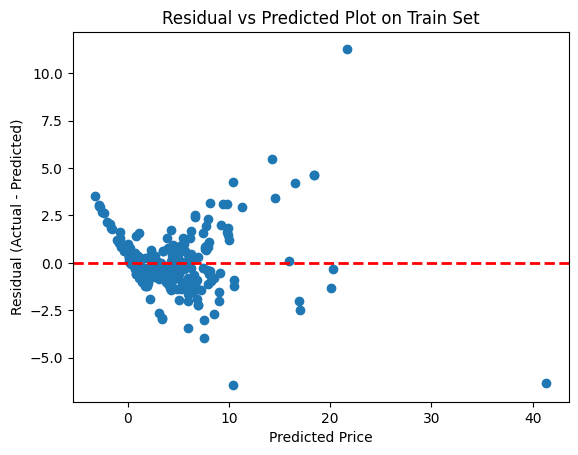

In [ ]:
residuals = y_train - y_train_pred
plt.scatter(y_train_pred, residuals)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual vs Predicted Plot on Train Set")
plt.show()